# Test PACE data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from netCDF4 import Dataset
import satpy

### load netCDF

In [2]:

# specify the path to your netCDF file
l2_nc_file = '/home/ariaa/HYPSO test code/data/PACE/PACE_OCI.20241226T115901.L2.SFREFL.V3_0.nc'
l2_nc_file_2 = '/home/ariaa/HYPSO test code/data/PACE/PACE_OCI.20241226T115401.L2.SFREFL.V3_0.nc'
l1b_nc_file = '/home/ariaa/HYPSO test code/data/PACE/PACE_OCI.20241226T115901.L1B.V3.nc'
l1b_nc_file_v2 = '/home/ariaa/HYPSO test code/data/PACE/PACE_OCI.20241226T115901.L1B.V2.nc'
l1c_nc_file = '/home/ariaa/HYPSO test code/data/PACE/PACE_OCI.20241226T115901.L1C.V3.5km.nc'

# open the NetCDF file
# l2_nc = Dataset(l2_nc_file, mode='r')
# l2_nc_2 = Dataset(l2_nc_file_2, mode='r')
l1b_nc = Dataset(l1b_nc_file, mode='r')
# l1c_nc = Dataset(l1c_nc_file, mode='r')

# print timestamps min and max values
# for var_name, var in l2_nc.groups['geophysical_data'].variables.items():
#     print(f"Variable: {var_name}")
#     print(var[:])


### print data overview

In [3]:
# for group in l1b_nc.groups.keys():
#     print(f"group:", group)
#     for var_name, var in l1b_nc.groups[group].variables.items():
#         print(f"Variable: {var_name}")
#         print(var[:].shape)

In [4]:
# # l1c_nc.groups['observation_data'].variables.items()
# for group in l1c_nc.groups.keys():
#     print(f"group:", group)
#     for var_name, var in l1c_nc.groups[group].variables.items():
#         print(f"Variable: {var_name}")
#         print(var[:].shape)

In [5]:
# for group in l2_nc.groups.keys():
#     print(f"group:", group)
#     for var_name, var in l2_nc.groups[group].variables.items():
#         print(f"Variable: {var_name}")
#         print(var[:].shape)

In [6]:
# for var_name, var in l1c_nc.groups['observation_data'].variables.items():
#     print(f"Variable: {var_name}")
#     print(var[:].shape)

In [7]:
# l1c_nc.groups['observation_data'].variables['qc'][:].shape

In [8]:
# l2_nc.groups['geophysical_data'].variables['rhos'][:].shape

### plot

In [9]:
l1b_capture_blue = l1b_nc.groups['observation_data'].variables['rhot_blue'][:]
l1b_capture_red = l1b_nc.groups['observation_data'].variables['rhot_red'][:]

In [10]:
# l2_capture = l2_nc.groups['geophysical_data'].variables['rhos'][:]

In [11]:
# l2_capture_2 = l2_nc_2.groups['geophysical_data'].variables['rhos'][:]

In [12]:

blue_bands = np.array(l1b_nc.groups["sensor_band_parameters"]['blue_wavelength'][:])

red_bands = np.array(l1b_nc.groups["sensor_band_parameters"]['red_wavelength'][:])

In [13]:
r,g,b = 630, 532, 465

rgb_bands = np.array([np.argmin(np.abs(np.concatenate((blue_bands, red_bands)) - color)) for color in [r, g, b]])
print(rgb_bands)

num_blue_bands = l1b_capture_blue.shape[0]

capture = np.zeros((l1b_capture_blue.shape[1], l1b_capture_blue.shape[2],3))
i = 0
for c in rgb_bands: 
    if c < num_blue_bands: 
        capture[:,:,i] = l1b_capture_blue[c, :,:]
    else: 
        capture[:,:,i] = l1b_capture_red[c - num_blue_bands, :, :]
    i += 1
print(capture.shape)

[131  89  62]
(1709, 1272, 3)


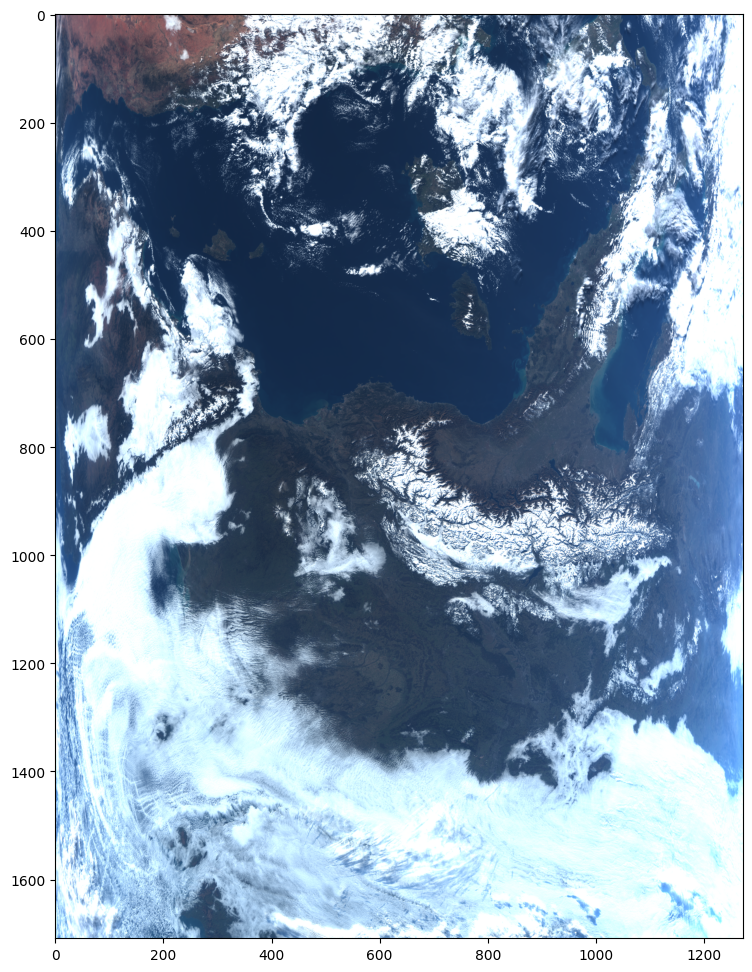

In [14]:
composite = (255*capture/(capture.max()))

composite_bright = composite * 3
composite_cliped = np.clip(composite_bright, 0, 255).astype('uint8')
composite_flipped = np.flip(composite_cliped, axis=0)

plt.figure(figsize=(12,12))
plt.imshow(composite_cliped)



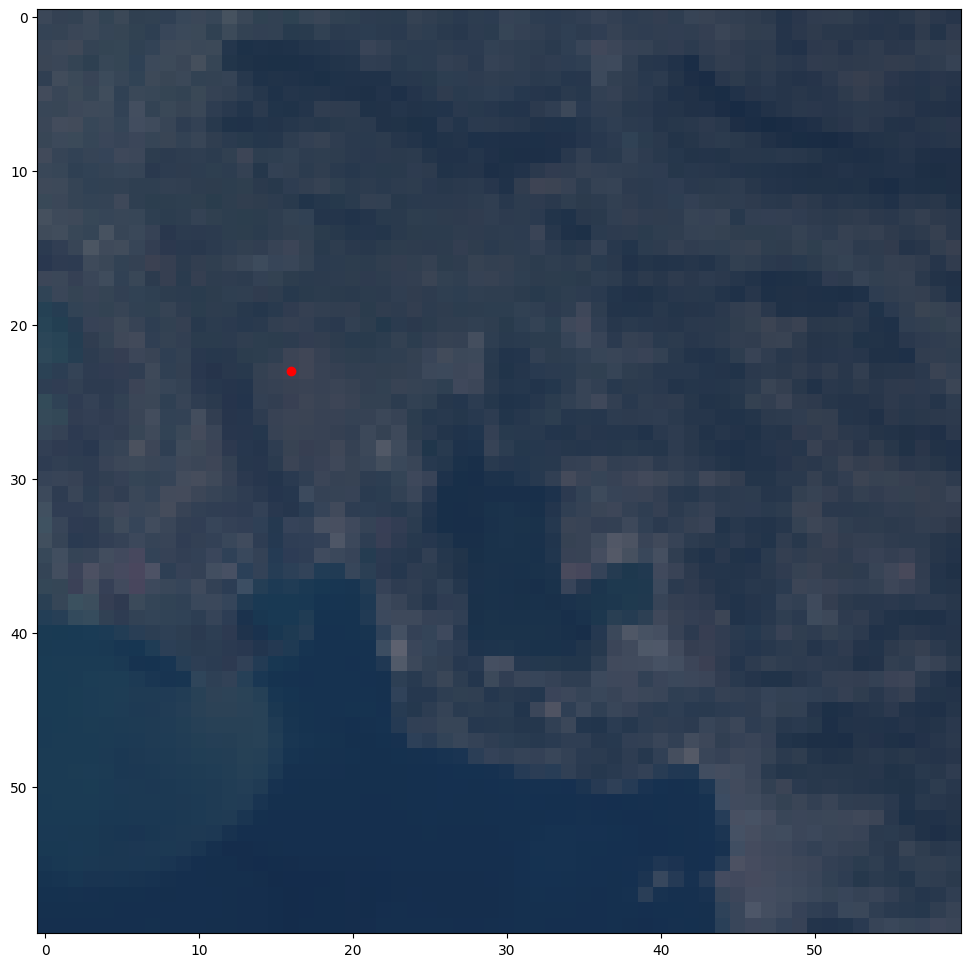

In [15]:
# plt.figure(figsize=(12,12))
# plt.imshow(composite_flipped[800:1100,400:600,:])

plt.figure(figsize=(12,12))
plt.imshow(composite_flipped[940:1000,490:550,:])
plt.plot(16, 23, 'ro') 


### outdated?

In [16]:
# rgb_bands = np.array([np.argmin(np.abs(np.arange(342.5, 887.5, 5) - color)) for color in [b, g, r]])

# plt.figure(figsize=(12, 12))
# plt.imshow(np.transpose(l1b_capture[rgb_bands, :, :], (1, 2, 0)))

In [17]:
# r, g, b = 630, 532, 465

# rgb_bands = np.array([np.argmin(np.abs(np.arange(342.5, 887.5, 5) - color)) for color in [b, g, r]])

# plt.figure(figsize=(12, 12))
# plt.imshow(np.transpose(l2_capture_2[:, :, rgb_bands], (1, 0, 2)))



In [18]:
# r,g,b = 630, 532, 465

# rgb_bands = np.array([np.argmin(np.abs(np.arange(342.5, 887.5, 5) - color)) for color in [b, g, r]])

# plt.figure(figsize=(12,12))
# plt.imshow(np.transpose(l2_capture[:, :, rgb_bands], (1, 0, 2)))

### Make merged hsi from blue and red cameras

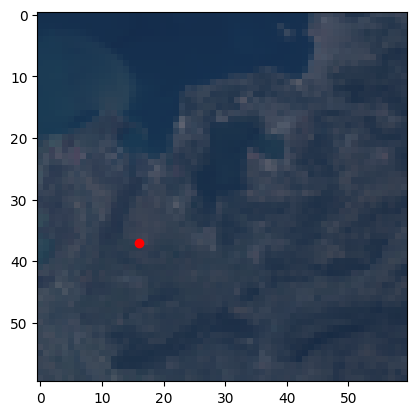

In [19]:
# plt.figure(figsize=(12,12))
plt.imshow(composite_cliped[-1000:-940,490:550,:])
plt.plot(16, 60-23, 'ro') 

#### plot radcalnet site on map

In [20]:
x_point = 16 + 490
y_point = 60-23 + composite_cliped.shape[0] - 1000
print(x_point, y_point)

506 746


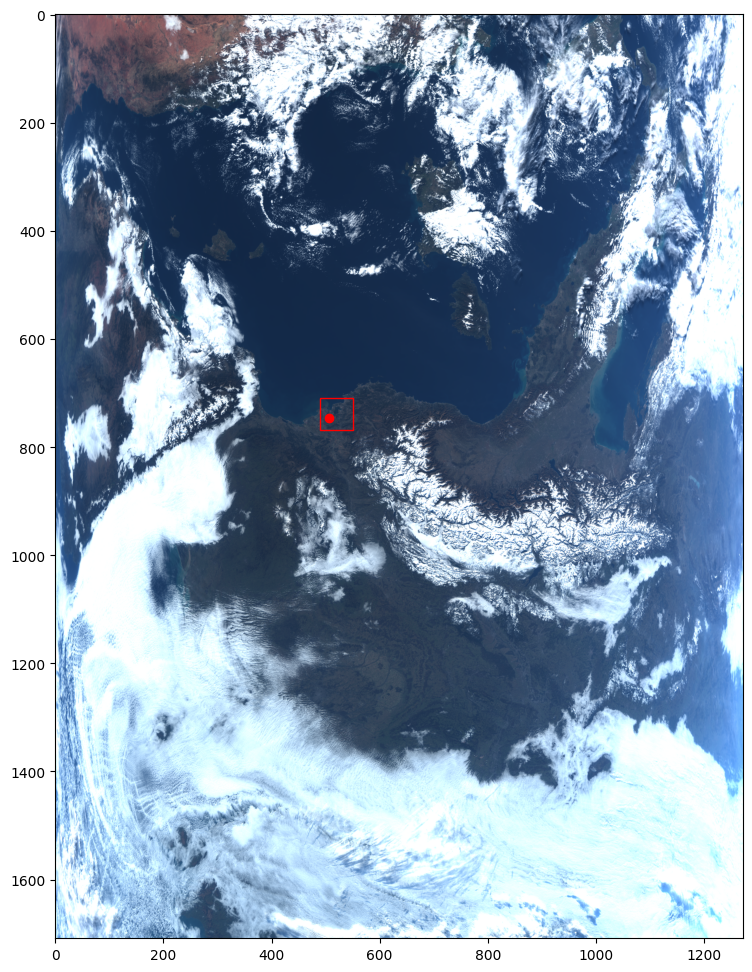

In [21]:
from matplotlib.patches import Rectangle

plt.figure(figsize=(12,12))
plt.imshow(composite_cliped[:,:,:])
plt.plot(x_point, y_point, 'ro')
plt.gca().add_patch(Rectangle((490, composite_cliped.shape[0]-1000),60,60,
                    edgecolor='red',
                    facecolor='none',
                    lw=1))

#### rest

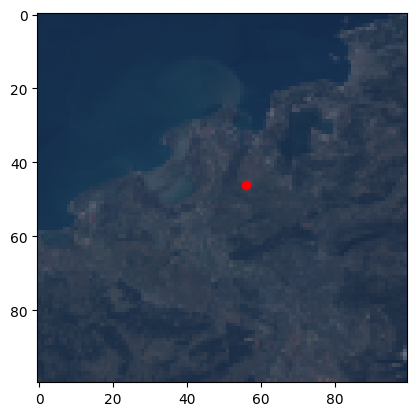

In [22]:
# find reduced capture for merging

x_point, y_point = 506, 746
x_min, x_max = 450,550
y_min, y_max = 700,800 
# plt.imshow(composite_cliped)

# plt.figure(figsize=(12,12))
plt.figure()
plt.imshow(composite_cliped[700:800,450:550,:])
plt.plot(x_point - x_min, y_point - y_min,  'ro')

In [23]:
overlaps_blue = []
overlaps_red = []
for i in range(len(blue_bands)): 
    if (blue_bands[i] > red_bands).any(): 
        idx = int(np.argmin(np.abs(red_bands - blue_bands[i])))
        overlaps_blue.append(i)
        overlaps_red.append(idx)

In [24]:
overlaps_blue, overlaps_red

([116, 117, 118], [0, 1, 2])

In [25]:
l1b_capture_blue_reduced = l1b_capture_blue[:, y_min:y_max,x_min:x_max]
l1b_capture_red_reduced = l1b_capture_red[:, y_min:y_max,x_min:x_max]

l_b, l_r, l_o = len(blue_bands), len(red_bands), len(overlaps_blue)

l1b_merged = np.zeros((l_b + l_r - l_o, l1b_capture_blue_reduced.shape[1], l1b_capture_blue_reduced.shape[2]))

l1b_merged[:l_b - l_o,:,:] = l1b_capture_blue_reduced[:-l_o,:,:]
l1b_merged[l_b - l_o:l_b ,:,:] = 0.5*(l1b_capture_blue_reduced[overlaps_blue,:,:] + l1b_capture_red_reduced[overlaps_red, :, :])
l1b_merged[l_b:, :, :] = l1b_capture_red_reduced[l_o:,:,:]

print(l1b_merged.shape)

(279, 100, 100)


In [26]:
bands_merged = np.zeros(l_b+l_r-l_o)

bands_merged[:l_b - l_o] = blue_bands[:-l_o]
bands_merged[l_b - l_o:l_b] = 0.5*(blue_bands[overlaps_blue] + red_bands[overlaps_red])
bands_merged[l_b:] = red_bands[l_o:]

print(bands_merged.shape)

(279,)


### plot La Crau spectrum

#### load H1,H2,radcalnet data from file

In [27]:
h1_lacrau_spectrum = np.load('h1_lacrau_spectrum.npz')['arr_0']
h2_lacrau_spectrum = np.load('h2_lacrau_spectrum.npz')['arr_0']
radcalnet_lacrau_spectrum = np.load('radcalnet_lacrau_spectrum.npz')['arr_0']


h1_lacrau_wavelengths = np.load('h1_lacrau_wavelengths.npz')['arr_0']
h2_lacrau_wavelengths = np.load('h2_lacrau_wavelengths.npz')['arr_0']
radcalnet_lacrau_wavelengths = np.load('radcalnet_lacrau_wavelengths.npz')['arr_0']

## plot

In [38]:
bands_merged.shape, bands_merged.max(), bands_merged.min()

((279,), np.float64(894.61474609375), np.float64(314.5071105957031))

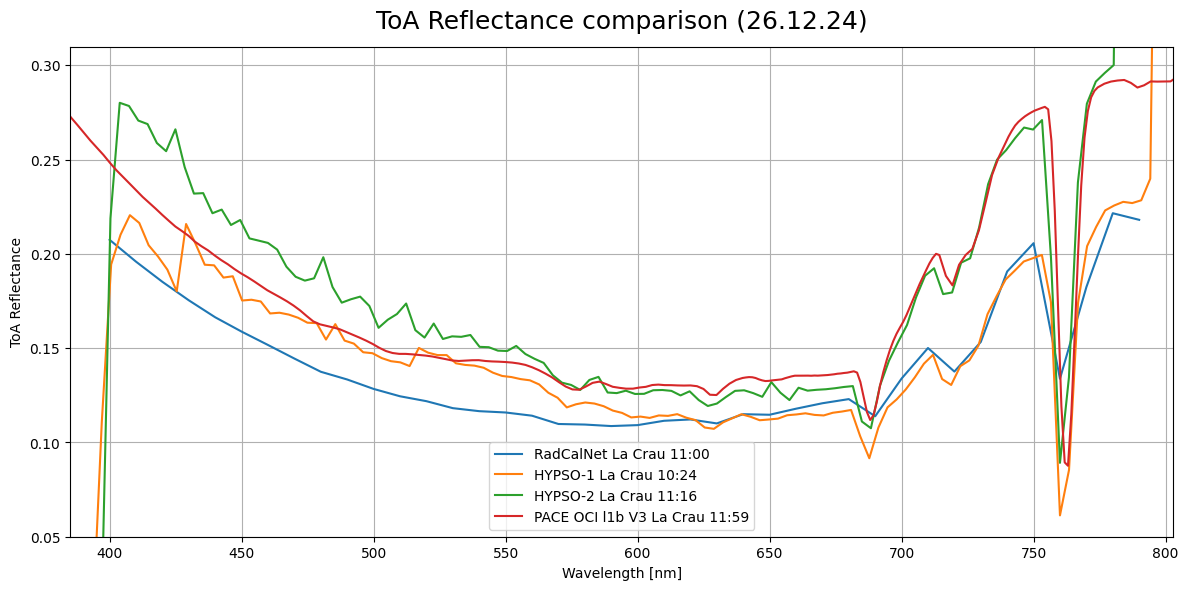

: 

In [ ]:
# pace_y, pace_x = 956, 513
x_gsp_h2, y_gsp_h2 = 305, 625
x_gsp_h1, y_gsp_h1 = 370, 470


x_min, x_max = 450,550
y_min, y_max = 700,800 

# manually found x and y limits for this particular case
x_limits = 385, 803
y_limits = 0.05, 0.31
# y_limits = 0.08, 0.3

region=1


plt.figure(figsize=(12,6))
plt.title('ToA Reflectance comparison (26.12.24)', fontsize=18, y=1.02)
plt.plot(radcalnet_lacrau_wavelengths, radcalnet_lacrau_spectrum)
plt.plot(h1_lacrau_wavelengths, h1_lacrau_spectrum) # wavelength mapping is not correct ...
plt.plot(h2_lacrau_wavelengths, h2_lacrau_spectrum)
plt.plot(bands_merged, l1b_merged[:, y_point - y_min, x_point - x_min])
plt.xlim(x_limits)
plt.ylim(y_limits)
plt.grid()
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Reflectance')
plt.legend(['RadCalNet La Crau 11:00', 'HYPSO-1 La Crau 10:24', 'HYPSO-2 La Crau 11:16', 'PACE OCI l1b V3 La Crau 11:59'])
# plt.legend(['HYPSO-2 La Crau 11:16', 'PACE OCI l1b V3 La Crau 11:59'])

plt.tight_layout()

## other

In [ ]:
print(satpy.available_readers() )

In [ ]:
if "oci_l2_bgc" in satpy.available_readers(): 
    print('true')
else: 
    print('false')

In [ ]:
l2_nc_file = '/home/ariaa/HYPSO test code/data/PACE/PACE_OCI.20241226T115901.L2.SFREFL.V3_0.nc'


### try nasa's tutorial

#### using finding data

In [ ]:
import earthaccess
import pathlib

In [ ]:
auth = earthaccess.login(persist=True)

In [ ]:
results = earthaccess.search_datasets(instrument="oci")

In [ ]:
for item in results:
    summary = item.summary()
    print(summary["short-name"])

In [ ]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC_NRT",
    count=1,
)

In [ ]:
tspan = ("2024-12-26", "2024-12-26")
bbox = (32.89336, -15.81851, 56.18805, 23.51935)
clouds = (0, 50)

In [ ]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)

#### loading data

In [ ]:
import cartopy.crs as ccrs
import earthaccess
import h5netcdf
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [ ]:
auth = earthaccess.login(persist=True)

In [ ]:
tspan = ("2024-12-26T10:00:00Z", "2024-12-26T13:00:00Z")
# bbox = (32.89336, -15.81851, 56.18805, 23.51935)
bbox = (56.18805, -15.81851 , 32.89336,  24.00023 )
# bbox = (43.5589 -1, 4.8642 -1, 43.5589 +1, 4.8642 +1)

results = earthaccess.search_data(
    short_name="PACE_OCI_L1B_SCI",
    temporal=tspan,
    bounding_box=bbox,
)

print(results)

In [ ]:
paths = earthaccess.open(results)

In [ ]:
# try:
#     paths[0].f.bucket
# except AttributeError:
#     raise "The result opened without an S3FileSystem."

In [ ]:
dataset = xr.open_dataset(paths[-2])
dataset

In [ ]:
with h5netcdf.File(paths[0]) as file:
    groups = list(file)
groups

In [ ]:
dataset = xr.open_dataset(paths[0], group="observation_data")
dataset

In [ ]:
dataset["rhot_blue"].sizes

In [ ]:
plot = dataset["rhot_blue"].sel({"blue_bands": 100}).plot()

In [ ]:
bands = xr.open_dataset(paths[0], group="sensor_band_parameters")['blue_wavelength']
# print(bands.values)
blue_bands = bands.values

bands = xr.open_dataset(paths[0], group="sensor_band_parameters")['red_wavelength']
# print(bands.values)
red_bands = bands.values

In [ ]:
r,g,b = 630, 532, 465

bgr_bands = np.array([np.argmin(np.abs(np.concatenate((blue_bands, red_bands)) - color)) for color in [b, g, r]])
print(bgr_bands)

num_blue_bands = dataset["rhot_blue"].shape[0]

capture = np.zeros((dataset["rhot_blue"].shape[1], dataset["rhot_blue"].shape[2],3))
i = 0
for c in bgr_bands: 
    if c < num_blue_bands: 
        capture[:,:,i] = dataset["rhot_blue"].isel(blue_bands=c)
    else: 
        capture[:,:,i] = dataset["rhot_red"].isel(red_bands= c - num_blue_bands)
    i += 1
print(capture.shape)

In [ ]:
plt.figure(figsize=(12,12))
plt.imshow(np.transpose(capture, (1,0,2)))